In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import percentileofscore

def monte_carlo_simulation(stock_data, num_simulations=1000, num_days=252):
    returns = np.log(1 + stock_data['Closing_Price'].pct_change())
    mu = returns.mean()
    sigma = returns.std()
    
    simulations = np.zeros((num_days, num_simulations))
    simulations[0] = stock_data['Closing_Price'].iloc[-1]
    
    for t in range(1, num_days):
        simulations[t] = simulations[t-1] * np.exp(mu + sigma * np.random.normal(0, 1, num_simulations))
    
    return simulations

def analyze_stocks(input_folder, output_folder):
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    
    stock_returns = {}
    all_stocks_data = []
    
    for filename in os.listdir(input_folder):
        if filename.endswith('.csv'):
            stock_name = filename[:-4]
            file_path = os.path.join(input_folder, filename)
            
            # Read stock data
            stock_data = pd.read_csv(file_path)
            stock_data['Date'] = pd.to_datetime(stock_data['Date'])
            stock_data = stock_data.sort_values('Date')
            
            # Perform Monte Carlo simulation
            simulations = monte_carlo_simulation(stock_data)
            
            # Calculate returns
            initial_price = stock_data['Closing_Price'].iloc[-1]
            final_prices = simulations[-1]
            returns = (final_prices - initial_price) / initial_price * 100
            
            min_return = np.min(returns)
            max_return = np.max(returns)
            avg_return = np.mean(returns)
            
            # Store data for CSV
            all_stocks_data.append({
                'Stock': stock_name,
                'Min Return (%)': min_return,
                'Max Return (%)': max_return,
                'Avg Return (%)': avg_return
            })
            
            # Store average return for top 25 calculation
            stock_returns[stock_name] = avg_return
            
            # Create and save graph
            plt.figure(figsize=(10, 6))
            plt.plot(simulations)
            plt.title(f'{stock_name} - Monte Carlo Simulation')
            plt.xlabel('Days')
            plt.ylabel('Stock Price')
            plt.savefig(os.path.join(output_folder, f'{stock_name}.png'))
            plt.close()
    
    # Create and save CSV with all stocks data
    all_stocks_df = pd.DataFrame(all_stocks_data)
    all_stocks_df.to_csv(os.path.join(output_folder, 'all_stocks_returns.csv'), index=False)
    
    # Sort stocks by average return and get top 25
    top_25_stocks = sorted(stock_returns.items(), key=lambda x: x[1], reverse=True)[:25]
    top_25_names = [stock[0] for stock in top_25_stocks]
    
    # Save top 25 stocks to a file
    with open(os.path.join(output_folder, 'top_25_stocks.txt'), 'w') as f:
        for stock, return_value in top_25_stocks:
            f.write(f"{stock}: {return_value:.2f}%\n")
    
    return top_25_names

# Specify input and output folders
input_folder = "/Users/hardikchoudhary/Documents/Fid/Fid-Case-Study/yahoo_finance/snp500_stock_data"
output_folder = "/Users/hardikchoudhary/Documents/Fid/Fid-Case-Study/yahoo_finance/monte_carlo_simulation/graphs"

# Run the analysis
top_25_stocks = analyze_stocks(input_folder, output_folder)

print(f"Analysis complete. Results saved in '{output_folder}'")
print("Top 25 stocks with best expected returns:")
print(top_25_stocks)
print(f"CSV file with all stocks' return data saved as 'all_stocks_returns.csv' in '{output_folder}'")

/var/folders/29/3chqsrwn1pzcg5t06fdj9ffm0000gn/T/ipykernel_18622/2488134199.py:34: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  stock_data['Date'] = pd.to_datetime(stock_data['Date'])
/var/folders/29/3chqsrwn1pzcg5t06fdj9ffm0000gn/T/ipykernel_18622/2488134199.py:34: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  stock_data['Date'] = pd.to_datetime(stock_data['Date'])
/var/folders/29/3chqsrwn1pzcg5t06fdj9ffm0000gn/T/ipykernel_18622/2488134199.py

Analysis complete. Results saved in '/Users/hardikchoudhary/Documents/Fid/Fid-Case-Study/yahoo_finance/monte_carlo_simulation/graphs'
Top 25 stocks with best expected returns:
['snp500_1year_combined_data', 'VST', 'GEV', 'NVDA', 'PLTR', 'SMCI', 'CEG', 'RCL', 'HWM', 'KKR', 'FICO', 'NRG', 'DELL', 'AVGO', 'GE', 'DVA', 'ANET', 'GDDY', 'MPWR', 'IRM', 'PHM', 'AXON', 'NFLX', 'MHK', 'MMM']
CSV file with all stocks' return data saved as 'all_stocks_returns.csv' in '/Users/hardikchoudhary/Documents/Fid/Fid-Case-Study/yahoo_finance/monte_carlo_simulation/graphs'


Sharpe Ratio Strategy

In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def create_combined_df(input_folder):
    all_data = []
    for filename in os.listdir(input_folder):
        if filename.endswith('.csv'):
            stock_name = filename[:-4]
            file_path = os.path.join(input_folder, filename)
            
            # Read stock data
            stock_data = pd.read_csv(file_path)
            stock_data['Date'] = pd.to_datetime(stock_data['Date'])
            stock_data = stock_data.sort_values('Date')
            stock_data = stock_data.set_index('Date')
            stock_data.columns = [f'{stock_name}_{col}' for col in stock_data.columns]
            all_data.append(stock_data)
    
    combined_df = pd.concat(all_data, axis=1)
    return combined_df

def calculate_sharpe_ratio(returns, risk_free_rate=0.02):
    excess_returns = returns - risk_free_rate / 252  # Assuming 252 trading days in a year
    return np.sqrt(252) * excess_returns.mean() / excess_returns.std()

def select_top_stocks(combined_df, num_stocks=25):
    # Calculate daily returns for all stocks
    price_columns = [col for col in combined_df.columns if col.endswith('_Closing_Price')]
    returns_df = combined_df[price_columns].pct_change()
    
    # Calculate Sharpe ratio for each stock
    sharpe_ratios = returns_df.apply(calculate_sharpe_ratio)
    
    # Select top stocks based on Sharpe ratio
    top_stocks = sharpe_ratios.nlargest(num_stocks)
    return top_stocks.index.str.replace('_Closing_Price', '')

def create_portfolio(combined_df, selected_stocks):
    portfolio_df = combined_df[[f'{stock}_Closing_Price' for stock in selected_stocks]]
    portfolio_df.columns = selected_stocks
    return portfolio_df

def calculate_portfolio_performance(portfolio_df):
    # Calculate daily returns
    returns = portfolio_df.pct_change()
    
    # Calculate equally-weighted portfolio returns
    portfolio_returns = returns.mean(axis=1)
    
    # Calculate cumulative returns
    cumulative_returns = (1 + portfolio_returns).cumprod()
    
    return cumulative_returns

def plot_portfolio_performance(cumulative_returns):
    plt.figure(figsize=(12, 6))
    plt.plot(cumulative_returns.index, cumulative_returns.values)
    plt.title('Portfolio Performance')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Returns')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('portfolio_performance.png')
    plt.close()

# Main execution
input_folder = "/Users/hardikchoudhary/Documents/Fid/Fid-Case-Study/yahoo_finance/snp500_stock_data"
num_stocks = 25

# Create combined DataFrame
print("Creating combined DataFrame...")
combined_df = create_combined_df(input_folder)
print("Combined DataFrame created.")

# Select top stocks
print(f"Selecting top {num_stocks} stocks...")
top_stocks = select_top_stocks(combined_df, num_stocks)
print(f"Selected top {num_stocks} stocks: {', '.join(top_stocks)}")

# Create portfolio
portfolio_df = create_portfolio(combined_df, top_stocks)

# Calculate portfolio performance
cumulative_returns = calculate_portfolio_performance(portfolio_df)

# Plot portfolio performance
plot_portfolio_performance(cumulative_returns)

print(f"Portfolio performance graph saved as '/Users/hardikchoudhary/Documents/Fid/Fid-Case-Study/yahoo_finance/monte_carlo_simulation/sharpe_strat_portfolio_performance.png'")
print(f"Final portfolio value: {cumulative_returns.iloc[-1]:.2f}")

# Additional portfolio statistics
total_return = cumulative_returns.iloc[-1] - 1
annualized_return = (1 + total_return) ** (252 / len(cumulative_returns)) - 1
annualized_volatility = portfolio_df.pct_change().mean(axis=1).std() * np.sqrt(252)
sharpe_ratio = calculate_sharpe_ratio(portfolio_df.pct_change().mean(axis=1))

print(f"\nPortfolio Statistics:")
print(f"Total Return: {total_return:.2%}")
print(f"Annualized Return: {annualized_return:.2%}")
print(f"Annualized Volatility: {annualized_volatility:.2%}")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")

Creating combined DataFrame...


/var/folders/29/3chqsrwn1pzcg5t06fdj9ffm0000gn/T/ipykernel_18622/460241244.py:15: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  stock_data['Date'] = pd.to_datetime(stock_data['Date'])
/var/folders/29/3chqsrwn1pzcg5t06fdj9ffm0000gn/T/ipykernel_18622/460241244.py:15: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  stock_data['Date'] = pd.to_datetime(stock_data['Date'])
/var/folders/29/3chqsrwn1pzcg5t06fdj9ffm0000gn/T/ipykernel_18622/460241244.py:15

Combined DataFrame created.
Selecting top 25 stocks...
Selected top 25 stocks: snp500_1year_combined_data, AMTM, SMCI, PLTR, GL, ENPH, DELL, VST, NVDA, PARA, MRNA, ALB, DXCM, GEV, CEG, FSLR, NCLH, TSLA, MPWR, AMD, ON, WBD, AVGO, MU, CRWD


/Users/hardikchoudhary/Library/Python/3.9/lib/python/site-packages/numpy/core/fromnumeric.py:59: RuntimeWarning: overflow encountered in accumulate
  return bound(*args, **kwds)
/Users/hardikchoudhary/Library/Python/3.9/lib/python/site-packages/matplotlib/axes/_base.py:2957: RuntimeWarning: overflow encountered in scalar add
  x0, x1 = inverse_trans.transform([x0t - delta, x1t + delta])


Portfolio performance graph saved as '/Users/hardikchoudhary/Documents/Fid/Fid-Case-Study/yahoo_finance/monte_carlo_simulation/sharpe_strat_portfolio_performance.png'
Final portfolio value: inf

Portfolio Statistics:
Total Return: inf%
Annualized Return: inf%
Annualized Volatility: 610.66%
Sharpe Ratio: 2.92


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import YearLocator, DateFormatter

def create_combined_df(input_folder):
    all_data = []
    for filename in os.listdir(input_folder):
        if filename.endswith('.csv'):
            stock_name = filename[:-4]
            file_path = os.path.join(input_folder, filename)
            
            # Read stock data
            stock_data = pd.read_csv(file_path)
            stock_data['Date'] = pd.to_datetime(stock_data['Date'])
            stock_data = stock_data.sort_values('Date')
            stock_data = stock_data.set_index('Date')
            stock_data.columns = [f'{stock_name}_{col}' for col in stock_data.columns]
            all_data.append(stock_data)
    
    combined_df = pd.concat(all_data, axis=1)
    return combined_df

def calculate_sharpe_ratio(returns, risk_free_rate=0.02):
    excess_returns = returns - risk_free_rate / 252  # Assuming 252 trading days in a year
    return np.sqrt(252) * excess_returns.mean() / excess_returns.std()

def select_top_stocks(combined_df, num_stocks=25):
    # Calculate daily returns for all stocks
    price_columns = [col for col in combined_df.columns if col.endswith('_Closing_Price')]
    returns_df = combined_df[price_columns].pct_change()
    
    # Calculate Sharpe ratio for each stock
    sharpe_ratios = returns_df.apply(calculate_sharpe_ratio)
    
    # Select top stocks based on Sharpe ratio
    top_stocks = sharpe_ratios.nlargest(num_stocks)
    return top_stocks.index.str.replace('_Closing_Price', '')

def create_portfolio(combined_df, selected_stocks):
    portfolio_df = combined_df[[f'{stock}_Closing_Price' for stock in selected_stocks]]
    portfolio_df.columns = selected_stocks
    return portfolio_df

def calculate_portfolio_performance(portfolio_df):
    # Calculate daily returns
    returns = portfolio_df.pct_change()
    
    # Calculate equally-weighted portfolio returns
    portfolio_returns = returns.mean(axis=1)
    
    # Calculate cumulative returns
    cumulative_returns = (1 + portfolio_returns).cumprod()
    
    return cumulative_returns

def plot_portfolio_performance(cumulative_returns, selected_stocks):
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(cumulative_returns.index, cumulative_returns.values, label='Portfolio')
    
    # Add S&P 500 benchmark if available
    if 'SPY_Closing_Price' in combined_df.columns:
        spy_returns = combined_df['SPY_Closing_Price'].pct_change().add(1).cumprod()
        ax.plot(spy_returns.index, spy_returns.values, label='S&P 500', linestyle='--')
    
    ax.set_title('Portfolio Performance')
    ax.set_xlabel('Date')
    ax.set_ylabel('Cumulative Returns')
    ax.grid(True)
    
    # Set x-axis to show years
    ax.xaxis.set_major_locator(YearLocator())
    ax.xaxis.set_major_formatter(DateFormatter('%Y'))
    
    # Rotate and align the tick labels so they look better
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # Add legend
    ax.legend()
    
    # Add text box with selected stocks
    stocks_text = '\n'.join(selected_stocks)
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    ax.text(0.05, 0.95, f'Selected Stocks:\n{stocks_text}', transform=ax.transAxes, fontsize=8,
            verticalalignment='top', bbox=props)
    
    plt.tight_layout()
    plt.savefig('portfolio_performance.png', dpi=300)
    plt.close()

# Main execution
input_folder = "/Users/hardikchoudhary/Documents/Fid/Fid-Case-Study/yahoo_finance/snp500_stock_data"
num_stocks = 25

# Create combined DataFrame
print("Creating combined DataFrame...")
combined_df = create_combined_df(input_folder)
print("Combined DataFrame created.")

# Select top stocks
print(f"Selecting top {num_stocks} stocks...")
top_stocks = select_top_stocks(combined_df, num_stocks)
print(f"Selected top {num_stocks} stocks: {', '.join(top_stocks)}")

# Save selected stocks to a text file
with open('selected_stocks.txt', 'w') as f:
    for stock in top_stocks:
        f.write(f"{stock}\n")
print("Selected stocks saved to 'selected_stocks.txt'")

# Create portfolio
portfolio_df = create_portfolio(combined_df, top_stocks)

# Calculate portfolio performance
cumulative_returns = calculate_portfolio_performance(portfolio_df)

# Plot portfolio performance
plot_portfolio_performance(cumulative_returns, top_stocks)
print(f"Portfolio performance graph saved as 'portfolio_performance.png'")

# Calculate and print portfolio statistics
total_return = cumulative_returns.iloc[-1] - 1
annualized_return = (1 + total_return) ** (252 / len(cumulative_returns)) - 1
annualized_volatility = portfolio_df.pct_change().mean(axis=1).std() * np.sqrt(252)
sharpe_ratio = calculate_sharpe_ratio(portfolio_df.pct_change().mean(axis=1))

print(f"\nPortfolio Statistics:")
print(f"Total Return: {total_return:.2%}")
print(f"Annualized Return: {annualized_return:.2%}")
print(f"Annualized Volatility: {annualized_volatility:.2%}")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")

Creating combined DataFrame...


/var/folders/29/3chqsrwn1pzcg5t06fdj9ffm0000gn/T/ipykernel_20536/2840920748.py:16: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  stock_data['Date'] = pd.to_datetime(stock_data['Date'])
/var/folders/29/3chqsrwn1pzcg5t06fdj9ffm0000gn/T/ipykernel_20536/2840920748.py:16: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  stock_data['Date'] = pd.to_datetime(stock_data['Date'])
/var/folders/29/3chqsrwn1pzcg5t06fdj9ffm0000gn/T/ipykernel_20536/2840920748.py

Combined DataFrame created.
Selecting top 25 stocks...
Selected top 25 stocks: BK, BSX, FI, LDOS, TMUS, IRM, GDDY, RTX, MSI, VST, TRGP, WAB, GE, CTAS, DVA, FICO, HIG, HWM, KKR, RCL, AXP, GEV, IBM, ICE, TT
Selected stocks saved to 'selected_stocks.txt'
Portfolio performance graph saved as 'portfolio_performance.png'

Portfolio Statistics:
Total Return: 101.20%
Annualized Return: 101.76%
Annualized Volatility: 13.00%
Sharpe Ratio: 5.34


In [2]:
combined_df

,CSCO_Closing_Price,CSCO_Stock,UAL_Closing_Price,UAL_Stock,TROW_Closing_Price,TROW_Stock,ISRG_Closing_Price,ISRG_Stock,NVR_Closing_Price,NVR_Stock,...,IEX_Closing_Price,IEX_Stock,BWA_Closing_Price,BWA_Stock,LRCX_Closing_Price,LRCX_Stock,BLK_Closing_Price,BLK_Stock,PPL_Closing_Price,PPL_Stock
Date,,,,,,,,,,,,,,,,,,,,,
2023-10-17 00:00:00-04:00,52.239574,CSCO,40.119999,UAL,96.309021,TROW,275.369995,ISRG,5840.000000,NVR,...,200.595215,IEX,38.955193,BWA,63.279560,LRCX,620.202515,BLK,23.355808,PPL
2023-10-18 00:00:00-04:00,52.074936,CSCO,36.240002,UAL,93.728035,TROW,275.519989,ISRG,5746.589844,NVR,...,194.415146,IEX,37.997845,BWA,62.528908,LRCX,601.277588,BLK,23.220749,PPL
2023-10-19 00:00:00-04:00,51.639126,CSCO,36.029999,UAL,93.078003,TROW,273.450012,ISRG,5563.549805,NVR,...,193.102142,IEX,37.612934,BWA,58.606247,LRCX,606.952148,BLK,22.979570,PPL
2023-10-20 00:00:00-04:00,51.261417,CSCO,35.090000,UAL,92.083855,TROW,266.910004,ISRG,5488.100098,NVR,...,190.268768,IEX,38.106411,BWA,58.450466,LRCX,599.464050,BLK,22.921684,PPL
2023-10-23 00:00:00-04:00,50.554432,CSCO,35.380001,UAL,91.261765,TROW,272.589996,ISRG,5505.689941,NVR,...,190.367508,IEX,37.731369,BWA,58.375500,LRCX,599.366577,BLK,22.844507,PPL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-09 00:00:00-04:00,53.560001,CSCO,59.430000,UAL,107.419998,TROW,490.380005,ISRG,9627.599609,NVR,...,207.052353,IEX,35.070000,BWA,82.860001,LRCX,955.919983,BLK,31.850000,PPL
2024-10-10 00:00:00-04:00,53.540001,CSCO,60.259998,UAL,108.000000,TROW,483.839996,ISRG,9485.549805,NVR,...,207.759995,IEX,34.889999,BWA,82.059998,LRCX,955.590027,BLK,31.469999,PPL
2024-10-11 00:00:00-04:00,54.250000,CSCO,61.799999,UAL,108.980003,TROW,484.779999,ISRG,9534.190430,NVR,...,211.490005,IEX,35.049999,BWA,82.889999,LRCX,990.260010,BLK,31.709999,PPL


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

# Function to calculate z-score for mean reversion
def calculate_zscore(price_series, window=20):
    rolling_mean = price_series.rolling(window=window).mean()
    rolling_std = price_series.rolling(window=window).std()
    z_score = (price_series - rolling_mean) / rolling_std
    return z_score

# Function to calculate daily returns
def calculate_returns(price_series):
    return price_series.pct_change()

# Function to calculate maximum drawdown
def calculate_max_drawdown(returns):
    cumulative_returns = (1 + returns).cumprod()
    rolling_max = cumulative_returns.expanding().max()
    drawdowns = cumulative_returns/rolling_max - 1
    return drawdowns.min()

# Function to select stocks based on mean reversion
def select_mean_reversion_stocks(df, num_stocks=25):
    stock_columns = [col for col in df.columns if 'Closing_Price' in col]
    stock_metrics = []
    
    for col in stock_columns:
        stock_name = col.replace('_Closing_Price', '')
        prices = df[col]
        returns = calculate_returns(prices)
        z_score = calculate_zscore(prices)
        
        # Calculate mean reversion metrics
        mean_zscore = z_score.mean()
        std_zscore = z_score.std()
        mean_reversion_score = abs(mean_zscore) / std_zscore
        
        stock_metrics.append({
            'stock': stock_name,
            'mean_reversion_score': mean_reversion_score,
            'price_column': col
        })
    
    # Sort stocks by mean reversion score
    stock_metrics.sort(key=lambda x: x['mean_reversion_score'], reverse=True)
    return stock_metrics[:num_stocks]

# Process the data and create portfolio
def create_portfolio(df):
    # Select top 25 mean reverting stocks
    selected_stocks = select_mean_reversion_stocks(df)
    selected_columns = [stock['price_column'] for stock in selected_stocks]
    
    # Calculate portfolio returns (equal weighted)
    portfolio_returns = pd.DataFrame()
    weight = 1.0 / len(selected_columns)
    
    for col in selected_columns:
        stock_returns = calculate_returns(df[col])
        portfolio_returns[col] = stock_returns * weight
    
    portfolio_returns['Total'] = portfolio_returns.sum(axis=1)
    return portfolio_returns

# Function to plot portfolio metrics
def plot_portfolio_metrics(portfolio_returns):
    cumulative_returns = (1 + portfolio_returns['Total']).cumprod()
    
    # Create figure with subplots
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 15))
    
    # Plot 1: Cumulative Returns
    cumulative_returns.plot(ax=ax1, title='Cumulative Portfolio Returns')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Cumulative Returns')
    
    # Plot 2: Daily Returns Distribution
    sns.histplot(portfolio_returns['Total'], kde=True, ax=ax2)
    ax2.set_title('Distribution of Daily Returns')
    ax2.set_xlabel('Daily Returns')
    ax2.set_ylabel('Frequency')
    
    # Plot 3: Drawdown
    drawdown = (cumulative_returns/cumulative_returns.expanding().max() - 1)
    drawdown.plot(ax=ax3, title='Portfolio Drawdown')
    ax3.set_xlabel('Date')
    ax3.set_ylabel('Drawdown')
    
    plt.tight_layout()
    plt.show()
    
    # Print key metrics
    print(f"Maximum Drawdown: {calculate_max_drawdown(portfolio_returns['Total']):.2%}")
    print(f"Total Return: {(cumulative_returns.iloc[-1] - 1):.2%}")
    print(f"Sharpe Ratio: {(portfolio_returns['Total'].mean() / portfolio_returns['Total'].std() * np.sqrt(252)):.2f}")


    


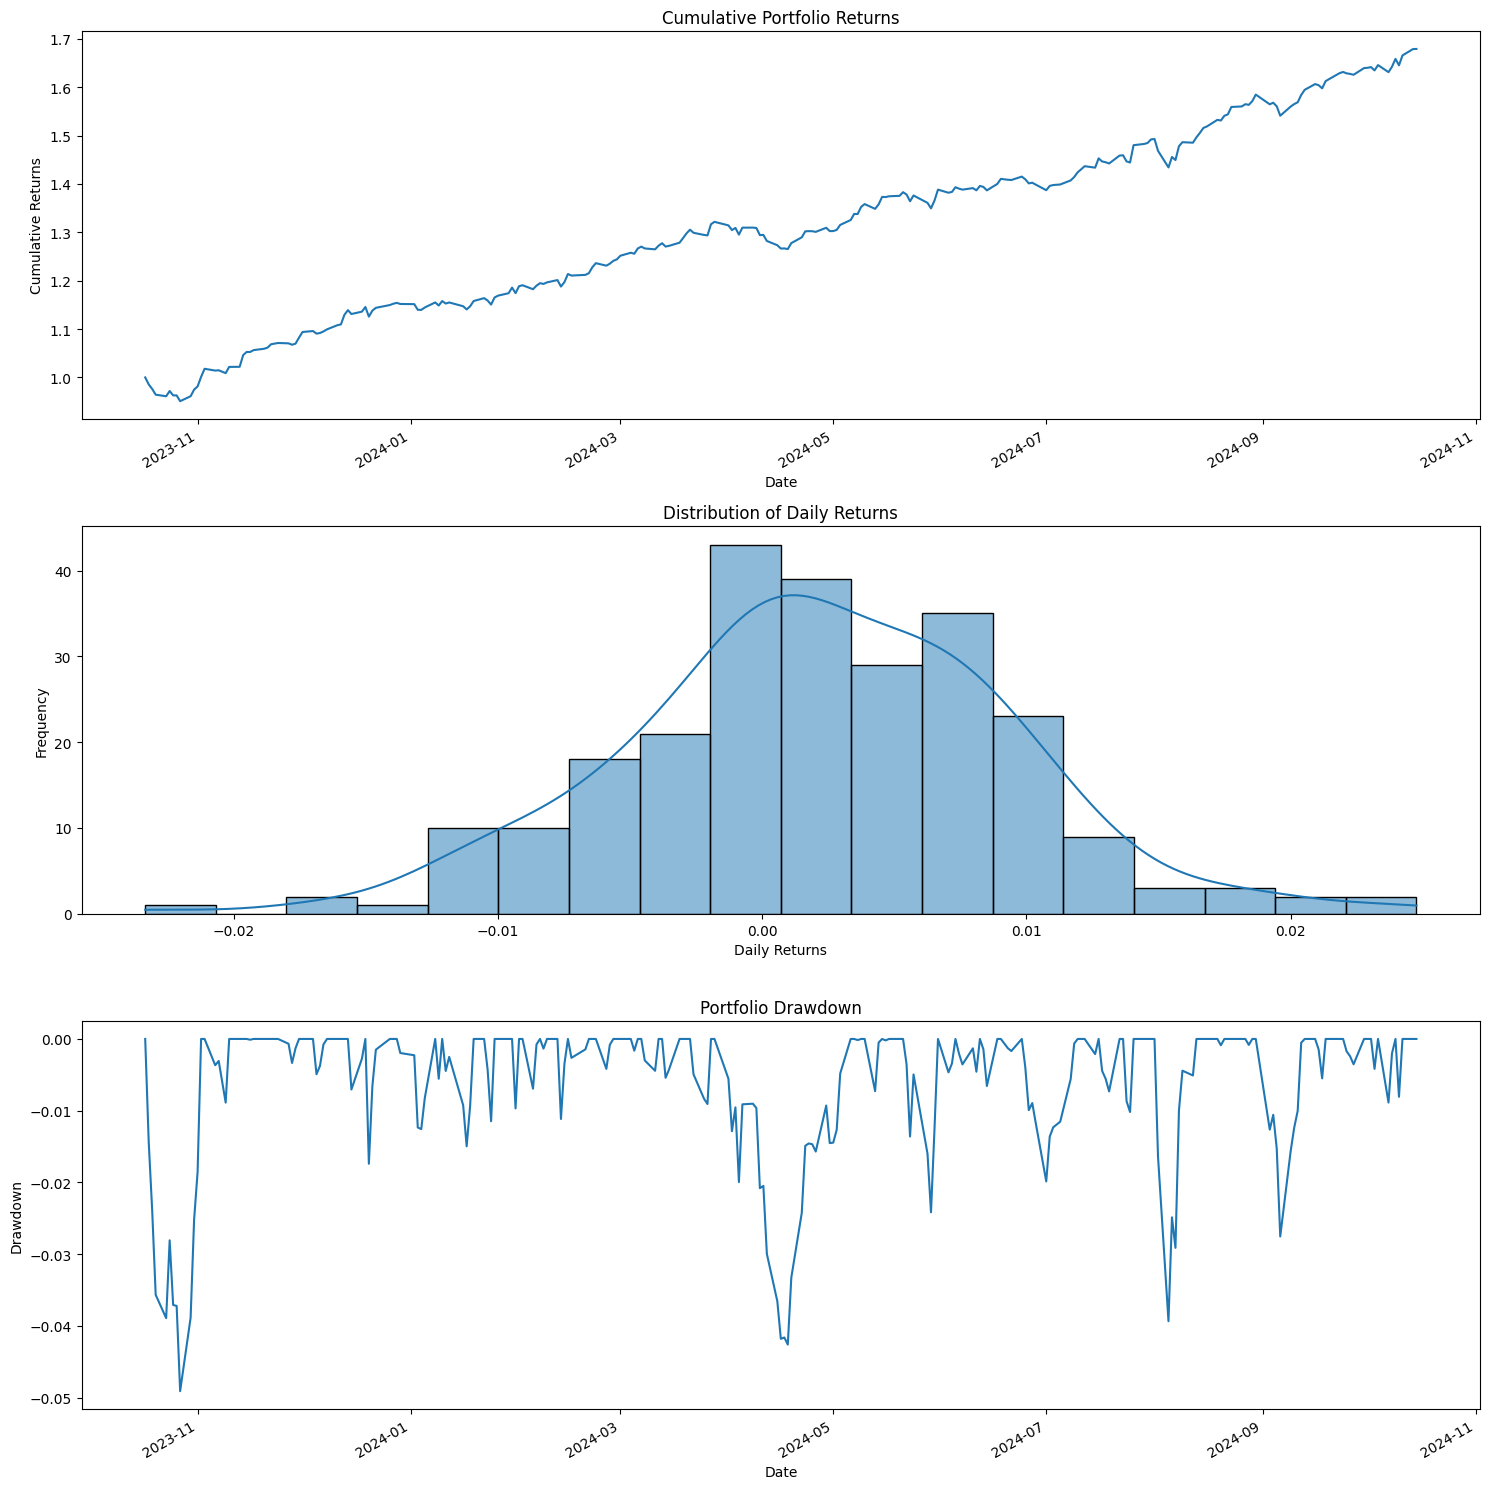

Maximum Drawdown: -4.91%
Total Return: 67.92%
Sharpe Ratio: 4.56


In [4]:
portfolio_returns = create_portfolio(combined_df)
plot_portfolio_metrics(portfolio_returns)


Monte Carlo Simulation Result Analysis


Portfolio Metrics:
      Annual Return  Annual Volatility  Sharpe Ratio  Skewness   Kurtosis  \
BK         0.580895           0.185543      3.130780  0.211380   2.432463   
BSX        0.460411           0.170384      2.702194  0.334294   6.486463   
FI         0.387303           0.179123      2.162211  0.045107   1.169282   
LDOS       0.489592           0.187119      2.616470  0.470847   7.110519   
TMUS       0.556301           0.158171      3.517099  0.081685   2.163595   
IRM        0.839907           0.232974      3.605153  0.004094   2.917731   
GDDY       0.573819           0.236994      2.421241  0.369353   3.213255   
RTX        0.489484           0.179206      2.731411  2.596459  18.633145   
MSI        0.559023           0.160795      3.476626  0.665691   4.160494   
VST        1.287861           0.641075      2.008909  0.351152   2.549169   
TRGP       0.721965           0.224427      3.216924 -1.008963   2.452999   
WAB        0.504504           0.236530      2.132939  1.

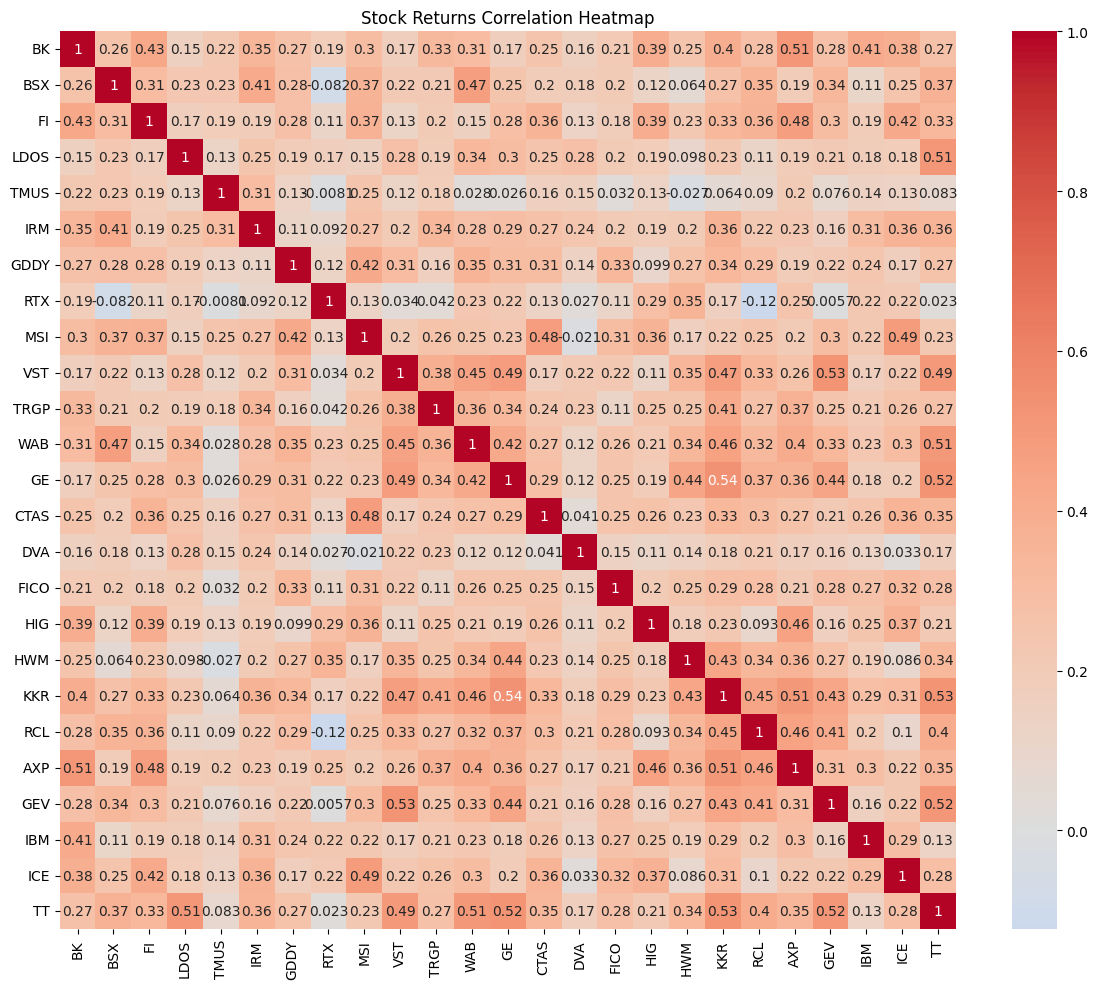

<Figure size 1200x600 with 0 Axes>

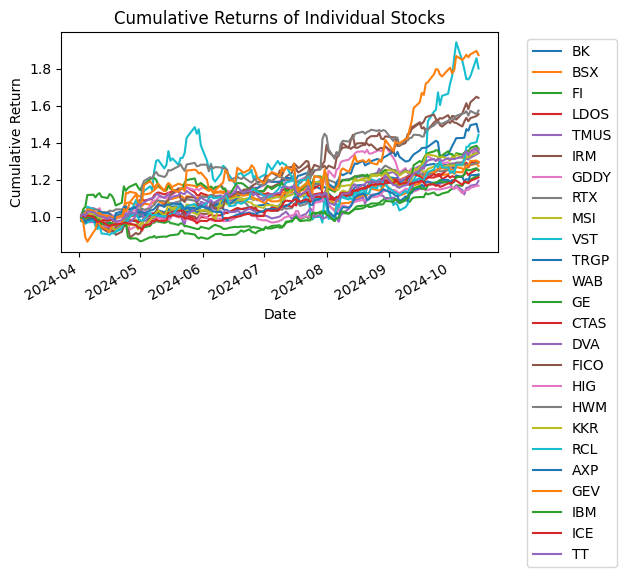

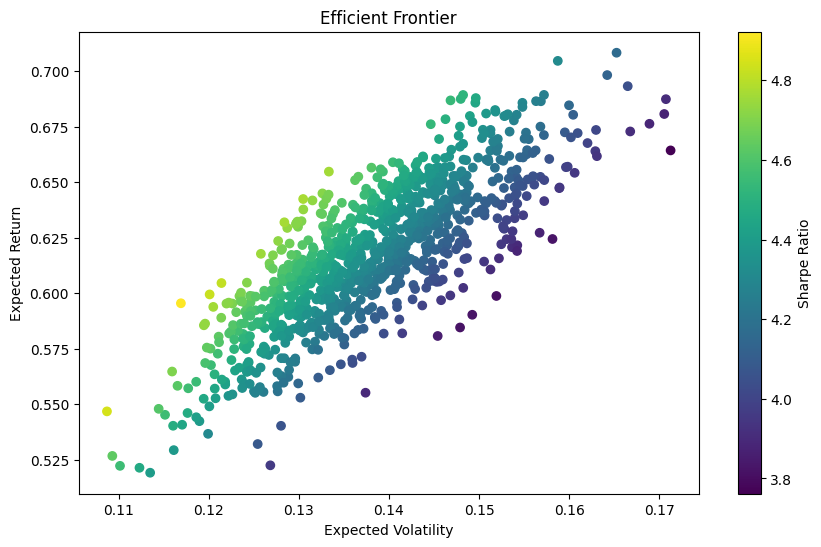


Maximum Drawdowns:
BK     -0.063476
BSX    -0.071638
FI     -0.083970
LDOS   -0.079256
TMUS   -0.050978
IRM    -0.080440
GDDY   -0.106027
RTX    -0.081981
MSI    -0.060238
VST    -0.348593
TRGP   -0.099060
WAB    -0.119911
GE     -0.079302
CTAS   -0.054532
DVA    -0.094102
FICO   -0.167896
HIG    -0.076908
HWM    -0.093574
KKR    -0.139490
RCL    -0.193108
AXP    -0.107177
GEV    -0.136037
IBM    -0.168622
ICE    -0.089467
TT     -0.118409
dtype: float64

Total Portfolio Return: 39.14%
Annualized Return: 83.60%


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.covariance import LedoitWolf

def prepare_data(df, stocks):
    # Get closing price columns for specified stocks
    price_data = pd.DataFrame()
    for stock in stocks:
        col_name = f"{stock}_Closing_Price"
        if col_name in df.columns:
            price_data[stock] = df[col_name]
    
    return price_data

def calculate_portfolio_metrics(returns_data):
    # Calculate key metrics
    annual_returns = returns_data.mean() * 252
    annual_volatility = returns_data.std() * np.sqrt(252)
    sharpe_ratio = annual_returns / annual_volatility
    
    # Calculate skewness and kurtosis
    skewness = returns_data.skew()
    kurtosis = returns_data.kurtosis()
    
    # Value at Risk (VaR) and Conditional VaR (CVaR)
    var_95 = returns_data.quantile(0.05)
    cvar_95 = returns_data[returns_data <= var_95].mean()
    
    metrics_df = pd.DataFrame({
        'Annual Return': annual_returns,
        'Annual Volatility': annual_volatility,
        'Sharpe Ratio': sharpe_ratio,
        'Skewness': skewness,
        'Kurtosis': kurtosis,
        'VaR (95%)': var_95,
        'CVaR (95%)': cvar_95
    })
    
    return metrics_df

def plot_correlation_heatmap(returns_data):
    plt.figure(figsize=(12, 10))
    correlation_matrix = returns_data.corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
    plt.title('Stock Returns Correlation Heatmap')
    plt.tight_layout()
    plt.show()

def plot_cumulative_returns(returns_data):
    cumulative_returns = (1 + returns_data).cumprod()
    plt.figure(figsize=(12, 6))
    cumulative_returns.plot()
    plt.title('Cumulative Returns of Individual Stocks')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Return')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

def plot_efficient_frontier(returns_data, num_portfolios=1000):
    returns = returns_data.mean() * 252
    cov_matrix = LedoitWolf().fit(returns_data).covariance_ * 252
    
    # Generate random portfolios
    returns_array = []
    volatility_array = []
    sharpe_array = []
    weights_array = []
    
    risk_free_rate = 0.02  # Assuming 2% risk-free rate
    
    for _ in range(num_portfolios):
        weights = np.random.random(len(returns))
        weights /= np.sum(weights)
        
        portfolio_return = np.sum(returns * weights)
        portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
        sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_volatility
        
        returns_array.append(portfolio_return)
        volatility_array.append(portfolio_volatility)
        sharpe_array.append(sharpe_ratio)
        weights_array.append(weights)
    
    plt.figure(figsize=(10, 6))
    plt.scatter(volatility_array, returns_array, c=sharpe_array, cmap='viridis', marker='o')
    plt.colorbar(label='Sharpe Ratio')
    plt.xlabel('Expected Volatility')
    plt.ylabel('Expected Return')
    plt.title('Efficient Frontier')
    plt.show()

def plot_rolling_metrics(returns_data, window=252):
    # Rolling volatility
    rolling_vol = returns_data.rolling(window=window).std() * np.sqrt(252)
    plt.figure(figsize=(12, 6))
    rolling_vol.plot()
    plt.title(f'{window}-Day Rolling Volatility')
    plt.xlabel('Date')
    plt.ylabel('Annualized Volatility')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    
    # Rolling beta relative to equal-weighted portfolio
    portfolio_returns = returns_data.mean(axis=1)
    rolling_betas = pd.DataFrame()
    
    for column in returns_data.columns:
        covariance = returns_data[column].rolling(window=window).cov(portfolio_returns)
        variance = portfolio_returns.rolling(window=window).var()
        rolling_betas[column] = covariance / variance
    
    plt.figure(figsize=(12, 6))
    rolling_betas.plot()
    plt.title(f'{window}-Day Rolling Beta to Equal-Weighted Portfolio')
    plt.xlabel('Date')
    plt.ylabel('Beta')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

def main_analysis(df, stocks):
    # Prepare data
    price_data = prepare_data(df, stocks)
    returns_data = price_data.pct_change().dropna()
    
    # Calculate and display metrics
    metrics = calculate_portfolio_metrics(returns_data)
    print("\nPortfolio Metrics:")
    print(metrics)
    
    # Plot various visualizations
    plot_correlation_heatmap(returns_data)
    plot_cumulative_returns(returns_data)
    plot_efficient_frontier(returns_data)
    #plot_rolling_metrics(returns_data)
    
    # Additional Risk Metrics
    max_drawdown = (price_data / price_data.expanding().max() - 1).min()
    print("\nMaximum Drawdowns:")
    print(max_drawdown)
    
    # Portfolio Composition Analysis
    equal_weight_return = returns_data.mean(axis=1)
    cumulative_portfolio_return = (1 + equal_weight_return).cumprod()
    print(f"\nTotal Portfolio Return: {(cumulative_portfolio_return.iloc[-1] - 1):.2%}")
    print(f"Annualized Return: {(cumulative_portfolio_return.iloc[-1] ** (252/len(cumulative_portfolio_return)) - 1):.2%}")

# Run the analysis
stocks = ['BK', 'BSX', 'FI', 'LDOS', 'TMUS', 'IRM', 'GDDY', 'RTX', 'MSI', 'VST', 
          'TRGP', 'WAB', 'GE', 'CTAS', 'DVA', 'FICO', 'HIG', 'HWM', 'KKR', 'RCL',
          'AXP', 'GEV', 'IBM', 'ICE', 'TT']

main_analysis(combined_df, stocks)